<a href="https://colab.research.google.com/github/beexy86-rgb/predikcija_kategorije_proizvoda/blob/main/notebooks/Task3_Predikcija_kategorije_proizvoda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **TASK 3: PREDIKCIJA KATEGORIJE PROIZVODA NA OSNOVU NASLOVA**

Cilj ovog zadatka je razvoj modela mašinskog učenja koji će automatski predlagati odgovarajuću kategoriju za svaki novi proizvod koji se postavi na online prodajnu platformu na osnovu njegovog naziva.

Na taj način proces unosa proizvoda na online platformi treba da bude brži, jednostavniji i precizniji, bez potrebe za ručnom klasifikacijom i sa manjom mogućnošću greške.

## **KORAK 1: PODACI**

Za kreiranje modela na raspolaganju nam je realan, bogat skup podataka (**products.csv**) sa **više od 30.000 proizvoda** iz različitih kategorija.

Skup sadrži sledeće informacije za svaki proizvod:

*   **Product ID** - jedinstveni identifikator;
*   **Product Title** - naziv proizvoda (npr. Samsung Galaxy A52 128GB);
*   **Merchant ID** - prodavac;
*   **Category Label** - ciljna kategorija (npr. Mobile Phones, Laptops) - OVO JE NAŠA CILJNA PROMENLJIVA ČIJU VREDNOST MODEL TREBA DA POGODI/PREDVIDI;
*   **Product Code** - interni kod;
*   **Number of Views** - broj pregleda;
*   **Merchant Rating** - ocena prodavca;
*   **Listing Date** - datum postavljanja.









In [111]:
#Importovanje  biblioteka potrebnih za rad
import pandas as pd

In [112]:
# load dataset from GitHub
url = "https://raw.githubusercontent.com/beexy86-rgb/predikcija_kategorije_proizvoda/main/products.csv"
df = pd.read_csv(url)

print("Broj redova:", len(df))
print("Prvih 5 redova:")
print(df.head())

Broj redova: 35311
Prvih 5 redova:
   product ID                                      Product Title  Merchant ID  \
0           1                    apple iphone 8 plus 64gb silver            1   
1           2                apple iphone 8 plus 64 gb spacegrau            2   
2           3  apple mq8n2b/a iphone 8 plus 64gb 5.5 12mp sim...            3   
3           4                apple iphone 8 plus 64gb space grey            4   
4           5  apple iphone 8 plus gold 5.5 64gb 4g unlocked ...            5   

   Category Label _Product Code  Number_of_Views  Merchant Rating  \
0   Mobile Phones    QA-2276-XC            860.0              2.5   
1   Mobile Phones    KA-2501-QO           3772.0              4.8   
2   Mobile Phones    FP-8086-IE           3092.0              3.9   
3   Mobile Phones    YI-0086-US            466.0              3.4   
4   Mobile Phones    NZ-3586-WP           4426.0              1.6   

   Listing Date    
0       5/10/2024  
1      12/31/2024  
2  

## **KORAK 2: EDA - EXPLORATORY DATA ANALYSIS**

U ovom koraku istražujemo skup podataka koji nam je na raspolaganju. Neophodno je da razumemo kakve podatke imamo, u kakvom su stanju i u kakvom međusobnom odnosu. Istražujemo sledeće:


*   da li postoje nedostajuće ili nekonzistentne vrednosti,
*   raspodelu kategorija proizvoda i drugih ključnih karakteristika,
*   da li postoje šabloni koji bi mogli pomoći u klasifikaciji proizvoda,
*   vizualizaciju svega što može da bude od koristi.

In [113]:
# Show column data types and non-null counts
print("\nDataset info:")
df.info()


Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35311 entries, 0 to 35310
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   product ID       35311 non-null  int64  
 1   Product Title    35139 non-null  object 
 2   Merchant ID      35311 non-null  int64  
 3    Category Label  35267 non-null  object 
 4   _Product Code    35216 non-null  object 
 5   Number_of_Views  35297 non-null  float64
 6   Merchant Rating  35141 non-null  float64
 7    Listing Date    35252 non-null  object 
dtypes: float64(2), int64(2), object(4)
memory usage: 2.2+ MB


Kolona *Product Title* sadrži i slova i brojeve i zato je tipa *object*. Za dalji rad potrebno je konvertovati je u tip *String*.

Kolona *Category label* takođe je tipa *object*, a potrebno je konvertovati u tip *category*.

Iz liste kolona može se primetiti da nazivi nekih kolona nisu idealni, jer sadrže prazna polja ili donje crte ispred naziva. To ćemo odmah promeniti kako se ne bismo "spoticali" u daljoj analizi zbog slovnih grešaka.

In [114]:
df.rename(columns={' Category Label': 'Category Label', '_Product Code': 'Product Code', ' Listing Date  ': 'Listing Date'}, inplace=True)

***Provera nedostajućih vrednosti***

In [115]:
# Broj nedostajućih vrednosti po koloni
print("Broj nedostajućih vrednosti po koloni:")
print(df.isna().sum())

Broj nedostajućih vrednosti po koloni:
product ID           0
Product Title      172
Merchant ID          0
Category Label      44
Product Code        95
Number_of_Views     14
Merchant Rating    170
Listing Date        59
dtype: int64


Najviše nedostajućih vrednosti nalazi se u kolonama *Product Title* i *Merchant Rating*. Međutim, mi model nećemo trenirati na podacima iz svih kolona. U ovom trenutku je sigurno da ćemo model trenirati na podacima iz kolona *Product Title* i *Category Label*. Jedan red - unos podataka je neupotrebljiv ako nedostaju vrednosti u jednoj od ove dve kolone. Zbog toga treba izbrisati sve redove u kojima nedostaju vrednosti u jednoj od ove dve kolone.

Pored navedenog, rešenje može biti i da se prazni redovi u koloni Category Label popune ručno na osnovu naslova proizvoda.

***Provera standardizovanosti unosa u koloni Category Label***

Naša ciljna promenljiva je *Category Label*. Vrlo je bitno da vidimo šta se u njoj dešava - pored toga što znamo da ima nedostajućih vrednosti, bitno je da vidimo i jedinstvene vrednosti i da razmotrimo da li su tu potrebne neke korekcije.

In [116]:
# Prebrojavanje različitih kategorija proizvoda
category_label_counts = df['Category Label'].value_counts()

# Prikaži jedinstvene vrednosti
print("Raspodela proizvoda po kategorijama:")
print(category_label_counts)

Raspodela proizvoda po kategorijama:
Category Label
Fridge Freezers     5495
Washing Machines    4036
Mobile Phones       4020
CPUs                3771
TVs                 3564
Fridges             3457
Dishwashers         3418
Digital Cameras     2696
Microwaves          2338
Freezers            2210
fridge               123
CPU                   84
Mobile Phone          55
Name: count, dtype: int64


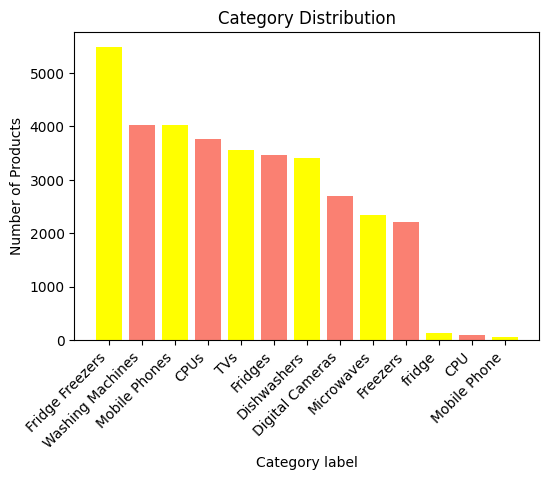

In [117]:
#Vizualizacija kategorija proizvoda
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
plt.bar(category_label_counts.index, category_label_counts.values, color=['yellow', 'salmon'])
plt.xticks(rotation=45, ha='right')
plt.title("Category Distribution")
plt.xlabel("Category label")
plt.ylabel("Number of Products")
plt.show()

Potrebno je standardizovati nazive kolona koji se odnose na kategoriju proizvoda "mobilni telefoni", "frižideri" i CPU.

## **KORAK 3: ČIŠĆENJE PODATAKA**

U ovom koraku treba da uklonimo nedostajuće vrednosti; standardizujemo oznake u koloni *Category Label*; postavimo odgovarajuće tipove podataka za sve kolone.

Cilj je da naš skup podataka bude:
*   čist (bez praznih i pogrešnih vrednosti);
*   konzistentan (isti format vrednosti u svim kolonama),
*   bez duplikata.



In [118]:
#Uklanjanje redova u kojima nedostaje vrednost u koloni Product Title ili Category Label
df.dropna(subset=['Product Title', 'Category Label'], inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 35096 entries, 0 to 35310
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   product ID       35096 non-null  int64  
 1   Product Title    35096 non-null  object 
 2   Merchant ID      35096 non-null  int64  
 3   Category Label   35096 non-null  object 
 4   Product Code     35002 non-null  object 
 5   Number_of_Views  35082 non-null  float64
 6   Merchant Rating  34926 non-null  float64
 7   Listing Date     35038 non-null  object 
dtypes: float64(2), int64(2), object(4)
memory usage: 2.4+ MB


Sada nemamo više 35311 unosa, već 35096 unosa.

In [119]:
#Konvertovanje vrednosti u koloni Product Title u string
df['Product Title'] = df['Product Title'].astype(str)
print('Novi tip podataka u koloni Product Title:', df['Product Title'].dtype)

Novi tip podataka u koloni Product Title: object


In [120]:
#Standardizacija vrednosti u koloni Category Label i konvertovanje u category tip podataka
df['Category Label'] = df['Category Label'].astype(str).str.lower().str.strip()

df['Category Label'] = df['Category Label'].replace('mobile phone', 'mobile phones')
df['Category Label'] = df['Category Label'].replace('cpu', 'cpus')
df['Category Label'] = df['Category Label'].replace('fridge', 'fridges')

df['Category Label'] = df['Category Label'].astype('category')
print('Novi tip podataka u koloni Category Label:', df['Category Label'].dtype)

Novi tip podataka u koloni Category Label: category


In [121]:
#Provera jedinstvenih vrednosti u koloni Category Label nakon standardizacije
category_label_counts_new = df['Category Label'].value_counts()

# Prikaži jedinstvene vrednosti nakon standardizacije
print("Raspodela proizvoda po kategorijama:")
print(category_label_counts_new)


Raspodela proizvoda po kategorijama:
Category Label
fridge freezers     5470
mobile phones       4057
washing machines    4015
cpus                3831
fridges             3559
tvs                 3541
dishwashers         3405
digital cameras     2689
microwaves          2328
freezers            2201
Name: count, dtype: int64


Na kraju želimo da proverimo duplikate. Pod duplikatima ovde podrazumevamo unose koji imaju iste vrednosti u kolonama Product Title i Category Label. Tako ćemo saznati da li je isti proizvod više puta ulistan na onlajn prodajnu platformu. Ostale kolone nam nisu bitne.

In [122]:
#Provera duplikata
duplikati = df[df.duplicated(subset=['Product Title', 'Category Label'], keep=False)]
print(duplikati)
print(duplikati.info())

       product ID                                      Product Title  \
3               4                apple iphone 8 plus 64gb space grey   
4               5  apple iphone 8 plus gold 5.5 64gb 4g unlocked ...   
5               6  apple iphone 8 plus gold 5.5 64gb 4g unlocked ...   
7               8                apple iphone 8 plus 64gb space grey   
8               9                apple iphone 8 plus 64gb space grey   
...           ...                                                ...   
34988       47016    iceq 15 litre deluxe portable mini fridge black   
34989       47017    iceq 15 litre deluxe portable mini fridge black   
35023       47052       liebherr kb 4350 freestanding fridge premium   
35213       47252                             built in larder fridge   
35250       47289             igenix fridge with icebox white ig3920   

       Merchant ID Category Label Product Code  Number_of_Views  \
3                4  mobile phones   YI-0086-US            466.0   
4

U skupu podataka postoji 7420 redova sa duplikatima (tu se računaju i prvi redovi i svi sledeći koji su mu identični). Potrebno je ukloniti sve duplikate, uz zadržavanje prvog reda.

In [123]:
df_cleaned = df.drop_duplicates(subset=['Product Title', 'Category Label'], keep='first')

In [124]:
print("Broj redova u dataframe-u nakon uklanjanja duplikata:", df_cleaned.shape[0])

Broj redova u dataframe-u nakon uklanjanja duplikata: 30826


Početni dataframe imao je 35311 unosa, a nakon uklanjanja nedostajućih vrednosti i duplikata iz interesnih kolona preostalo je 30826 validnih unosa. Dakle, **u odnosu na početni skup, za dalju analizu preostalo je** (30826/35311)*100% = **87% podataka**.

Još jednom proveravamo da li se broj nenedostajućih vrednosti u kolonama Product Title i Category Label slaže.

In [125]:
df_cleaned.info() # slaže se, u obe kolone ima 30826 nenedostajućih vrednosti

<class 'pandas.core.frame.DataFrame'>
Index: 30826 entries, 0 to 35310
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype   
---  ------           --------------  -----   
 0   product ID       30826 non-null  int64   
 1   Product Title    30826 non-null  object  
 2   Merchant ID      30826 non-null  int64   
 3   Category Label   30826 non-null  category
 4   Product Code     30741 non-null  object  
 5   Number_of_Views  30816 non-null  float64 
 6   Merchant Rating  30672 non-null  float64 
 7   Listing Date     30772 non-null  object  
dtypes: category(1), float64(2), int64(2), object(3)
memory usage: 1.9+ MB


## **KORAK 4: INŽENJERING KARAKTERISTIKA**

U ovom koraku razmotrićemo koje kolone su svrsishodne za model, a koje ne. Sve kolone koje ne doprinose modelu, uklonićemo.

Nepotrebne kolone, jer vrednosti u njima ne govore ništa značajno o samoj kategoriji proizvoda: product ID, Merchant ID, Product Code, Number_of_Views, Merchant Rating, Listing Date.
Ove kolone će biti uklonjene iz skupa podataka.

Svrsishodne kolone:

*   *Product Title* - kolona na osnovu čijih vrednosti ćemo prognozirati kategoriju proizvoda: NEZAVISNA PROMENLJIVA za naš model.
*   *Category Label* - kolona u kojoj je određena kategorija proizvoda: ZAVISNO PROMENLJIVA za naš model.



In [126]:
df_filtered = df_cleaned.drop(columns=['product ID', 'Merchant ID', 'Product Code', 'Number_of_Views', 'Merchant Rating', 'Listing Date'])
df_filtered.head()


,Product Title,Category Label
0,apple iphone 8 plus 64gb silver,mobile phones
1,apple iphone 8 plus 64 gb spacegrau,mobile phones
2,apple mq8n2b/a iphone 8 plus 64gb 5.5 12mp sim...,mobile phones
3,apple iphone 8 plus 64gb space grey,mobile phones
4,apple iphone 8 plus gold 5.5 64gb 4g unlocked ...,mobile phones


U koloni *Product Title* mogu se kriti još neki podaci koji bi bili od koristi za model koji prognozira kategoriju proizvoda.

In [127]:
print(df_filtered[df['Category Label'] == 'mobile phones'].tail
 (50))

                                      Product Title Category Label
4031    nokia n73 mobile phone music edition silver  mobile phones
4032        motorola motorizr z3 black mobile phone  mobile phones
4033                      samsung d840 mobile phone  mobile phones
4034                  motorola l6 pink mobile phone  mobile phones
4035                        nokia 6085 mobile phone  mobile phones
4036                   nokia 7373 pink mobile phone  mobile phones
4037                         nokia n95 mobile phone  mobile phones
4038             motorola moto krzr k1 mobile phone  mobile phones
4039                     samsung d900 ultra edition  mobile phones
4040                              lg u880 pink muse  mobile phones
4041                  motorola v3i d g mobile phone  mobile phones
4042                        nokia 2310 mobile phone  mobile phones
4043                        nokia 1112 mobile phone  mobile phones
4044       sony ericsson w710i walkman mobile phone  mobile ph

/tmp/ipykernel_649/3413765625.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  print(df_filtered[df['Category Label'] == 'mobile phones'].tail


***Razmatranje ključnih reči***

Pokušano je da se uoče ključne reči koje se pojavljuju u većini nazivu proizvoda koji pripadaju određenoj kategoriji. Na osnovu toga je formirana nova kolona koja beleži pojavu tih reči u nazivu.

In [128]:
#keywords_fridge_freezers = ['frost', 'fridge', 'cm', 'litre']
#keywords_phones = ['sim', 'galaxy', 'iphone', 'handy', 'phone', 'smartphone', 'xperia', 'android']
#keywords_washing_machines = ['kg', 'spin', 'rpm']
#keywords_cpus = ['ghz']
#keywords_tvs = ['inch', 'led', 'hd', 'hdr', '4k']
#keywords_dishwashers = ['cm', 'dish']
#keywords_digital_cameras = ['mp', 'zoom', 'mm']
#keywords_microwaves = ['oven', 'wave']

keywords = ['frost', 'fridge', 'cm', 'litre', 'sim', 'galaxy', 'iphone', 'handy', 'phone', 'smartphone', 'xperia', 'android', 'kg', 'spin', 'rpm', 'ghz', 'inch', 'led', 'hd', 'hdr', '4k', 'dish', 'mp', 'zoom', 'mm', 'oven', 'wave']

#Funkcija za pronalaženje ključnih reči
def pronadji_kljucne_reci(naslov):
    naslov_mali = str(naslov).lower()
    pronadjene_reci = []
    for rec in keywords:
        if rec in naslov_mali:
            pronadjene_reci.append(rec) # Ako reč postoji u naslovu, ubaci je u listu
    return pronadjene_reci

#Primena funkcije na kolonu
df_filtered['Keywords'] = df_filtered['Product Title'].apply(pronadji_kljucne_reci)

#Da vidimo kako sada izgleda dataframe
print(df_filtered.head(10))
print(df_filtered.tail(10))


                                        Product Title Category Label  \
0                     apple iphone 8 plus 64gb silver  mobile phones   
1                 apple iphone 8 plus 64 gb spacegrau  mobile phones   
2   apple mq8n2b/a iphone 8 plus 64gb 5.5 12mp sim...  mobile phones   
3                 apple iphone 8 plus 64gb space grey  mobile phones   
4   apple iphone 8 plus gold 5.5 64gb 4g unlocked ...  mobile phones   
6                apple iphone 8 plus 64 gb space grey  mobile phones   
10  apple iphone 8 plus 5.5 single sim 4g 64gb silver  mobile phones   
11    sim free iphone 8 plus 64gb by apple space grey  mobile phones   
12           apple iphone 8 plus 64gb gold smartphone  mobile phones   
13    apple iphone 8 plus 5.5 single sim 4g 64gb grey  mobile phones   

                                Keywords  
0                        [iphone, phone]  
1                        [iphone, phone]  
2   [sim, iphone, phone, smartphone, mp]  
3                        [iphone, p

Nova kolona Keywords može biti značajna za model.

***Razmatranje dužine naziva proizvoda***

Izračunata je dužina svakog naziva proizvoda i pokušano je da se vizuelno zaključi da li može postojati neka veza između dužine naziva i kategorije kojoj proizvod pripada.

Product title length summary:
count    30826.000000
mean        52.759456
std         22.621606
min          5.000000
25%         38.000000
50%         51.000000
75%         65.000000
max        200.000000
Name: length, dtype: float64
Product title length statistics by product category:
                   count       mean        std   min   25%   50%   75%    max
Category Label                                                               
cpus              3043.0  68.640158  21.461714  11.0  55.0  66.0  78.0  190.0
digital cameras   2405.0  49.308524  23.453294   6.0  34.0  44.0  60.0  180.0
dishwashers       3042.0  50.164366  18.339502  10.0  39.0  51.0  61.0  192.0
freezers          1903.0  48.591172  18.324478  10.0  37.0  47.0  60.0  168.0
fridge freezers   4809.0  55.118112  20.478982   9.0  42.0  54.0  68.0  170.0
fridges           3190.0  48.542633  18.490933   8.0  36.0  46.0  62.0  173.0
microwaves        2094.0  51.663324  18.842923  11.0  39.0  52.0  65.0  164.0
mobile pho

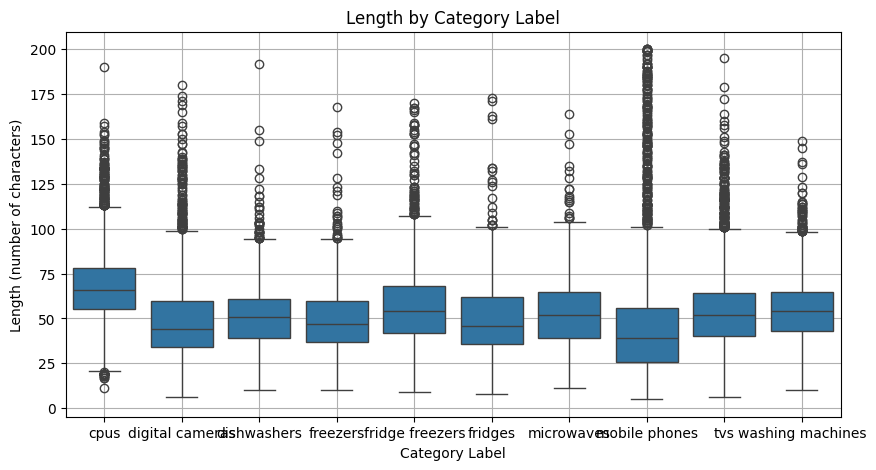

In [129]:
#Izračunavanje dužine naziva proizvoda
df_filtered['length'] = df_filtered['Product Title'].astype(str).str.len()
# Deskriptivna statistika
print("Product title length summary:")
print(df_filtered['length'].describe())

# Grupisanje po kategoriji proizvoda
print("Product title length statistics by product category:")
print(df_filtered.groupby('Category Label', observed=False)['length'].describe())

# Vizualizacije raspodele dužine naziva proizvoda po kategoriji proizvoda
plt.figure(figsize=(10, 5))
sns.boxplot(data=df_filtered, x='Category Label', y='length')
plt.title("Length by Category Label")
plt.xlabel("Category Label")
plt.ylabel("Length (number of characters)")
plt.grid(True)
plt.show()


Srednje vrednosti dužine naziva proizvoda su uglavnom slične, kao i rasponi 25%-75%, a u svim kategorijama proizvodu pojavljuju se izuzetno dugi nazivi. Jedino se može izdvojiti CPUs, kod kojih je prosečna dužina naziva nešto duža u odnosu na ostale kategorije. Po mišljenju autora, ova karakteristika nije značajna za model.